## Ananya Verma
### Roll No. = MCS24018

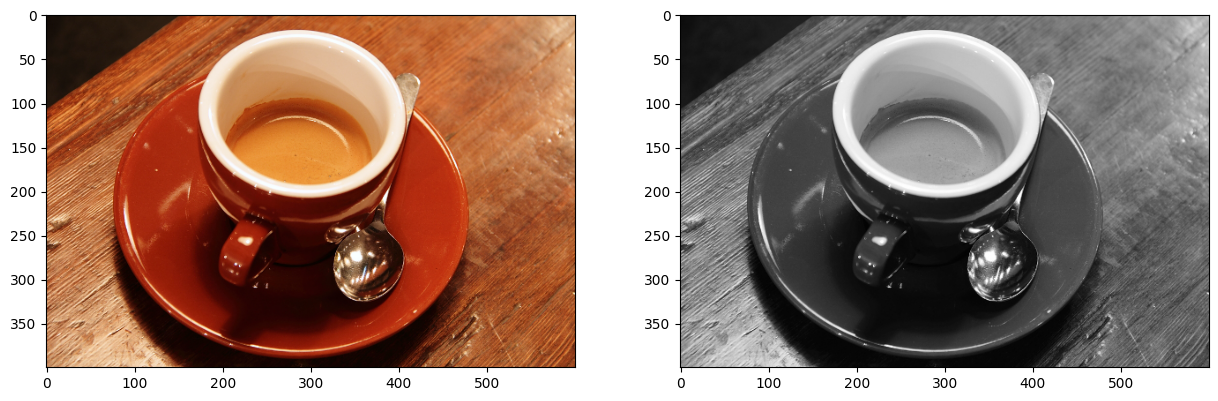

In [ ]:
# Importing Necessary Libraries
from skimage import data #data module of skimage contains the sample images for image processing
from skimage.color import rgb2gray #rbg2gray function converts an RGB image to grayscale
import matplotlib.pyplot as plt #for plotting and displaying images

# Setting the plot size to 15,15
plt.figure(figsize=(15, 15))

# Sample Image of scikit-image package
coffee = data.coffee()
plt.subplot(1, 2, 1)

# Displaying the sample image in the first subplot
plt.imshow(coffee)

# Converting RGB image to Monochrome (Grayscale image)
gray_coffee = rgb2gray(coffee)
plt.subplot(1, 2, 2)

# Displaying the sample image - Monochrome
# display the grayscale image in the second subplot
plt.imshow(gray_coffee, cmap="gray")

In [ ]:
# List all available sample images
print(dir(data))

['astronaut', 'binary_blobs', 'brain', 'brick', 'camera', 'cat', 'cell', 'cells3d', 'checkerboard', 'chelsea', 'clock', 'coffee', 'coins', 'colorwheel', 'data_dir', 'download_all', 'eagle', 'file_hash', 'grass', 'gravel', 'horse', 'hubble_deep_field', 'human_mitosis', 'immunohistochemistry', 'kidney', 'lbp_frontal_face_cascade_filename', 'lfw_subset', 'lily', 'logo', 'microaneurysms', 'moon', 'nickel_solidification', 'page', 'palisades_of_vogt', 'protein_transport', 'retina', 'rocket', 'shepp_logan_phantom', 'skin', 'stereo_motorcycle', 'text', 'vortex']


Segmentation by Thresholding – Manual Input

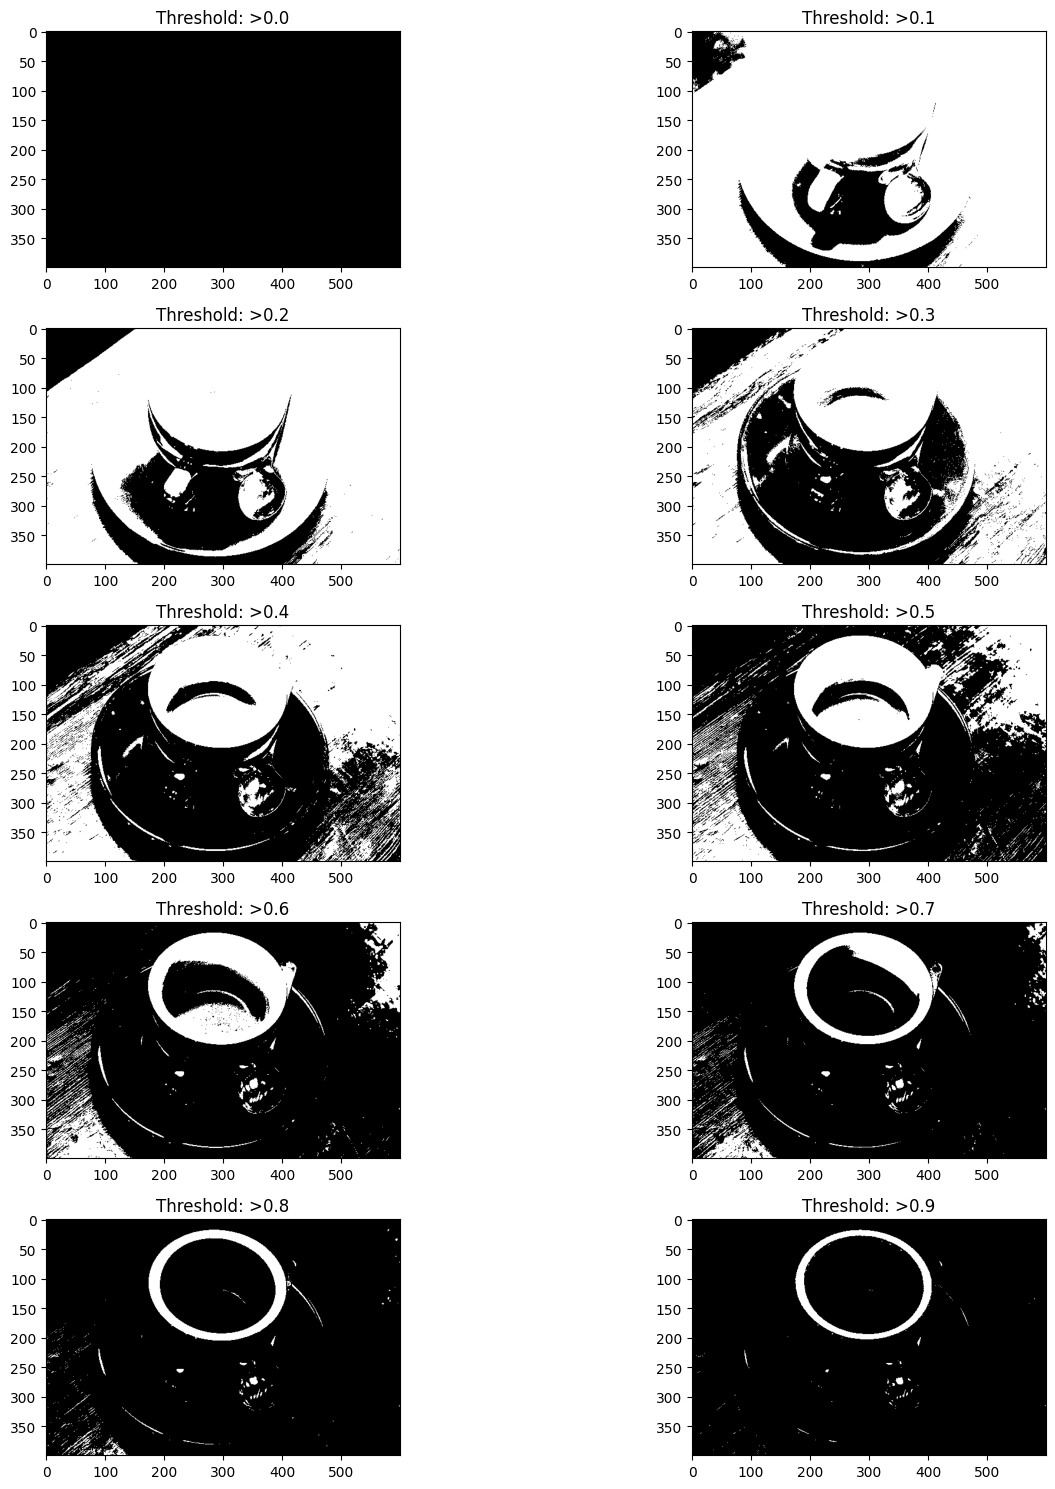

In [ ]:
# Importing Necessary Libraries
# Displaying the sample image - Monochrome Format
from skimage import data
from skimage import filters # not used in the code, this is typically used for filtering operations
from skimage.color import rgb2gray
import matplotlib.pyplot as plt

# Sample Image of scikit-image package
coffee = data.coffee()
gray_coffee = rgb2gray(coffee) # image converted to grayscale here the pixel intensity range from 0 (black) to 1 (white)

# Setting the plot size to 15,15 for vizualization
plt.figure(figsize=(15, 15))

# loop to apply and display the thresholding with different levels
for i in range(10):

  # Iterating different thresholds
  # applying the binary thresholding at different levels
  # if the pixel intensity > threshold (pixels brighter than threshold will become white), set it to 1 (white), else 0 (black)
  # here i = 0 menas threshold = 0.0 and i = 1 means threshold = 0.1... so on.
  # 1 is multiplied to convert the boolean values into numeric values
  binarized_gray = (gray_coffee > i*0.1)*1 # creates a binary (black & white) version of the grayscale image using a threshold
  plt.subplot(5,2,i+1)

  # using the round() function to format the threshold value
  # round(i * 0.1, 1) ensures the value has only 1 decimal place
  # this avoids floating-point precision errors (e.g., 0.20000000000000004 instead of 0.2) also makes the title easier to read and ensures uniform formatting
  plt.title("Threshold: >"+str(round(i*0.1,1)))

  # Displaying the binarized image
  # of various thresholds
  plt.imshow(binarized_gray, cmap = 'gray')

plt.tight_layout()

Active Contour Segmentation

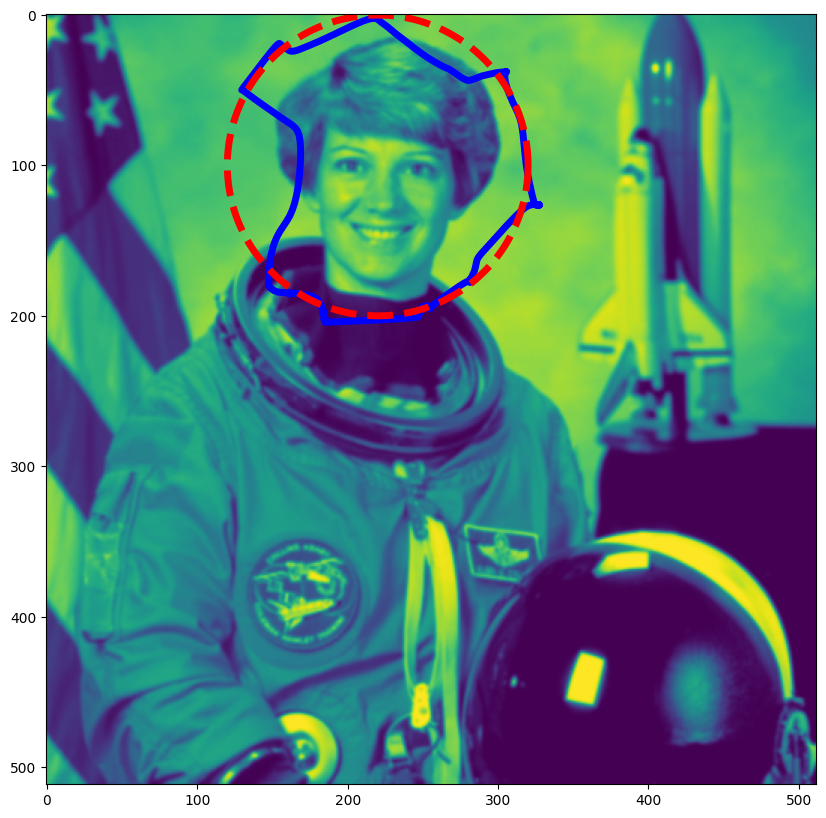

In [ ]:
# importing necessary libraries
import numpy as np  # numerical operations
import matplotlib.pyplot as plt  # plotting and visualization
from skimage.color import rgb2gray  # convert rgb image to grayscale
from skimage import data  # load sample images
from skimage.filters import gaussian  # apply gaussian filter for smoothing
from skimage.segmentation import active_contour  # perform active contour segmentation (snakes)

# Sample Image of scikit-image package
astronaut = data.astronaut()
gray_astronaut = rgb2gray(astronaut) # convert the image to grayscale since active contour works on 2d image

# Applying Gaussian Filter to remove noise and smooth the image
gray_astronaut_noiseless = gaussian(gray_astronaut, 1) # sigma=1 controls the blur strength

# Localising the circle's center at 220, 110
# define an initial circular contour around the astronaut's face
# np.linspace(0, 2 * np.pi, 500) generates 500 equally spaced points from 0 to 2pi
# np.cos(...) and np.sin(...) compute the x and y components of the circular shape respectively
x1 = 220 + 100 * np.cos(np.linspace(0, 2 * np.pi, 500)) # x-coordinates of the circle
x2 = 100 + 100 * np.sin(np.linspace(0, 2 * np.pi, 500)) # y-coordinates of the circle

# stack the x1 and x2 arrays as columns to form (x, y) coordinate pairs
snake = np.array([x1, x2]).T # shape: (500, 2), each row is a (x, y) point

# Computing the Active Contour for the given image
# perform active contour segmentation (snakes algorithm)
astronaut_snake = active_contour(gray_astronaut_noiseless, snake) # adjusts the contour to match object boundary
astronaut_snake_no_blur = active_contour(gray_astronaut, snake)
# the active_contour function modifies the points in 'snake' to fit the object's edges in the image
# it optimizes an energy function that considers:
# 1. internal energy – maintains smoothness of the contour
# 2. external energy – attracts the contour to strong edges in the image
# 3. image energy – helps align the contour with image features

# initially, 'snake' forms a rough circular contour around the astronaut's face
# after active_contour, 'astronaut_snake' is the refined contour that closely follows the face boundary


fig = plt.figure(figsize=(10, 10))

# Adding subplots to display the markers
ax = fig.add_subplot(111)

# display the grayscale image (after noise reduction)
ax.imshow(gray_astronaut_noiseless)

# Plotting the face boundary marker
# plot the refined contour after active contour segmentation
ax.plot(astronaut_snake[:, 0], astronaut_snake[:, 1], '-b', lw=5) # blue line with line width = 5

# Plotting the circle around face
# plot the initial circular contour before refinement
ax.plot(snake[:, 0], snake[:, 1], '--r', lw=5) # red dashed line with line width = 5

plt.show()


### Image segmentation without applying the gaussian filter

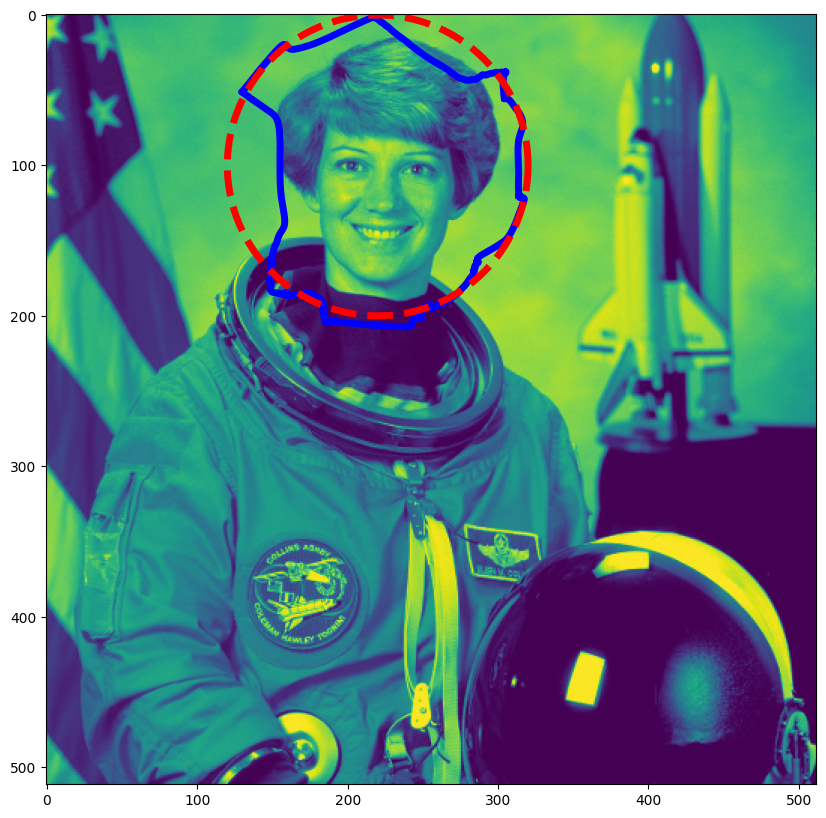

In [ ]:
x1 = 220 + 100 * np.cos(np.linspace(0, 2 * np.pi, 500))
x2 = 100 + 100 * np.sin(np.linspace(0, 2 * np.pi, 500))
snake = np.array([x1, x2]).T

astronaut_snake = active_contour(gray_astronaut, snake)

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111)
ax.imshow(gray_astronaut)
ax.plot(astronaut_snake[:, 0], astronaut_snake[:, 1], '-b', lw=5)
ax.plot(snake[:, 0], snake[:, 1], '--r', lw=5)

plt.show()


<ipython-input-8-514986b74a71>:2: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  im = imageio.imread("bird_sit.jpg")


<class 'numpy.ndarray'> (1080, 1920, 3) uint8


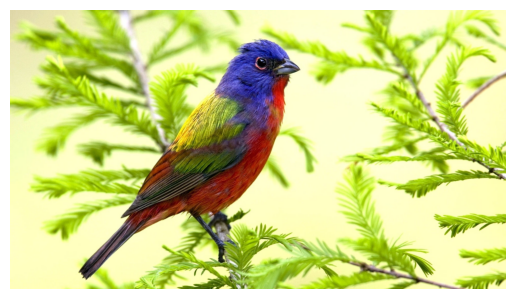

(<matplotlib.image.AxesImage at 0x7e4e83354890>,
 (np.float64(-0.5), np.float64(1919.5), np.float64(1079.5), np.float64(-0.5)),
 None)

In [ ]:
import imageio
im = imageio.imread("bird_sit.jpg")
print(type(im), im.shape, im.dtype)
plt.imshow(im), plt.axis('off'), plt.show()

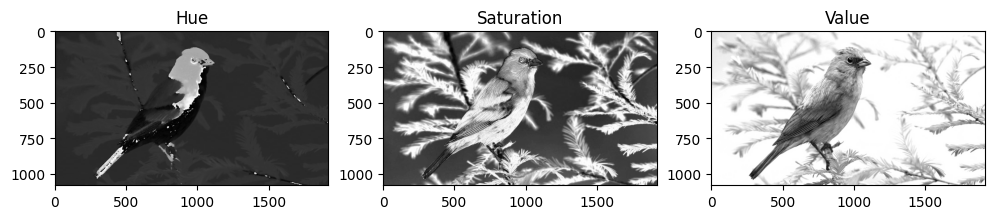

In [ ]:
# importing necessary libraries
from skimage.color import rgb2hsv  # function to convert RGB image to HSV color space

# converting the RGB image to HSV
im_hsv = rgb2hsv(im)  # 'im_hsv' now contains the image in HSV format

fig, ax = plt.subplots(1, 3, figsize=(12, 4))  # creating subplots to display the three channels (Hue, Saturation, Value)

# displaying the Hue channel - Hue (H): Represents the type of color (e.g., red, blue, green) as an angle from 0° to 360° (but normalized between 0 and 1 in Python)
ax[0].imshow(im_hsv[:, :, 0], cmap='gray')  # extracting and displaying the first channel (Hue) in grayscale
ax[0].set_title('Hue')

# displaying the Saturation channel - Saturation (S): Represents the intensity of the color (0 = grayscale, 1 = full color)
ax[1].imshow(im_hsv[:, :, 1], cmap='gray')  # extracting and displaying the second channel (Saturation) in grayscale
ax[1].set_title('Saturation')

# displaying the Value channel - Value (V): Represents brightness (0 = black, 1 = full brightness).
ax[2].imshow(im_hsv[:, :, 2], cmap='gray')  # extracting and displaying the third channel (Value) in grayscale
ax[2].set_title('Value')

plt.show()  # displaying the plots


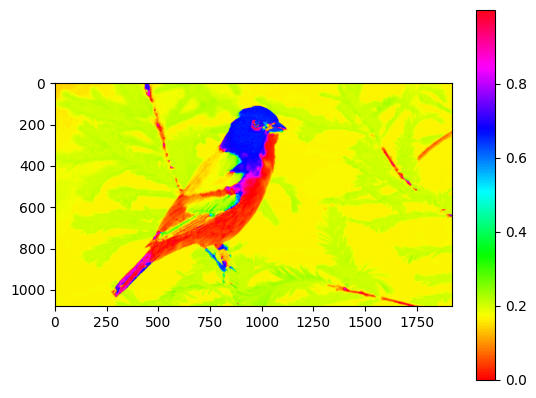

In [ ]:
plt.imshow(im_hsv[:,:,0],cmap='hsv')
plt.colorbar()

Let us now try to threshold the image using the Hue par of the HSV color channel to segment the image.

# Red

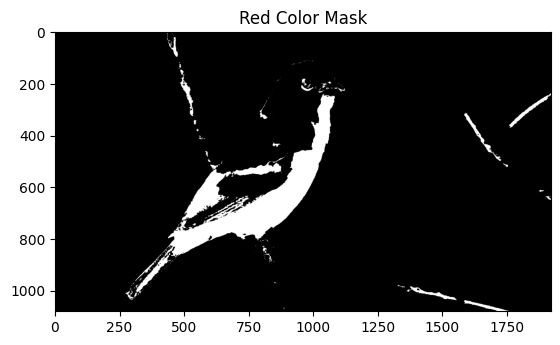

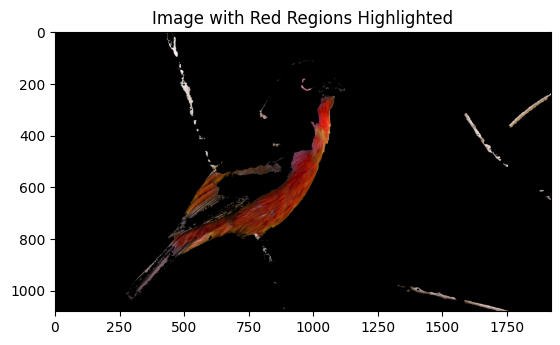

In [ ]:
from skimage.io import imread, imshow # imread to load an image, imshow to display an image

# creating a mask to detect red hues in the image
# selecting pixels where the hue is either greater than 0.90 (reddish) or less than 0.10 (reddish)
lower_mask = (im_hsv[:, :, 0] > 0.90) | (im_hsv[:, :, 0] < 0.10)  # boolean mask for red hues

# ensuring that all selected pixels have a valid hue value
upper_mask = im_hsv[:, :, 0] < 1  # boolean mask to include only valid hue values

# combining both masks to get the final mask for red color
mask = upper_mask * lower_mask  # element-wise multiplication to combine conditions

# displaying the mask (binary image showing red pixels as white and others as black)
plt.imshow(mask, cmap='gray')
plt.title("Red Color Mask")
plt.show()

# extracting red, green, and blue channels based on the mask
red = im[:, :, 0] * mask  # keeping red channel values where mask is True
green = im[:, :, 1] * mask  # keeping green channel values where mask is True
blue = im[:, :, 2] * mask  # keeping blue channel values where mask is True

# stacking the masked RGB channels to reconstruct the image with only red-highlighted regions
im_masked = np.dstack((red,green,blue))

# displaying the masked image with red areas highlighted
plt.imshow(im_masked)
plt.title("Image with Red Regions Highlighted")
plt.show()

# Yellow

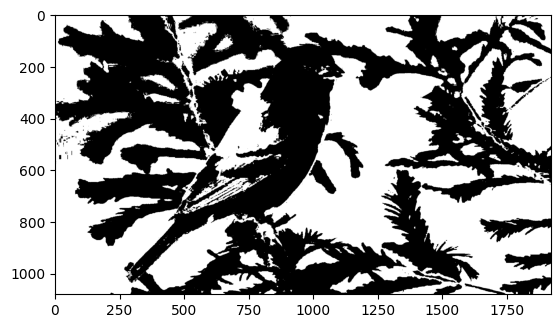

<ipython-input-12-4b7234f5f1dd>:19: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  imshow(im_masked)


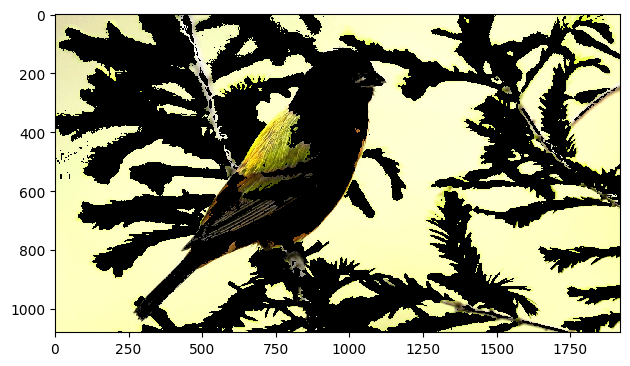

In [ ]:
# creating a mask to detect yellow hues in the image
lower_mask = im_hsv[:, :, 0] > 0.08  # lower hue threshold for yellow
upper_mask = im_hsv[:, :, 0] < 0.19  # upper hue threshold for yellow
mask = upper_mask * lower_mask  # combining both masks

# displaying the mask
plt.imshow(mask, cmap='gray')
plt.show()

# extracting RGB channels based on the mask
red = im[:, :, 0] * mask
green = im[:, :, 1] * mask
blue = im[:, :, 2] * mask

# reconstructing the image with only yellow-highlighted regions
im_masked = np.dstack((red, green, blue))

# displaying the masked image
imshow(im_masked)
plt.show()


# Blue

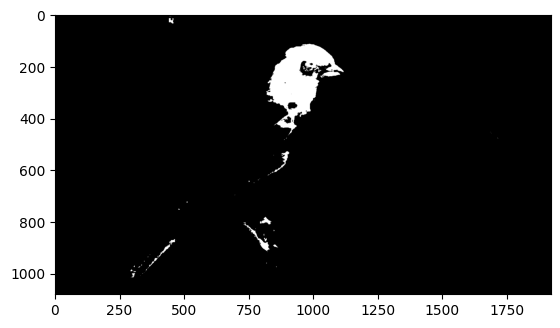

<ipython-input-13-6a5637295a4a>:19: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  imshow(im_masked)


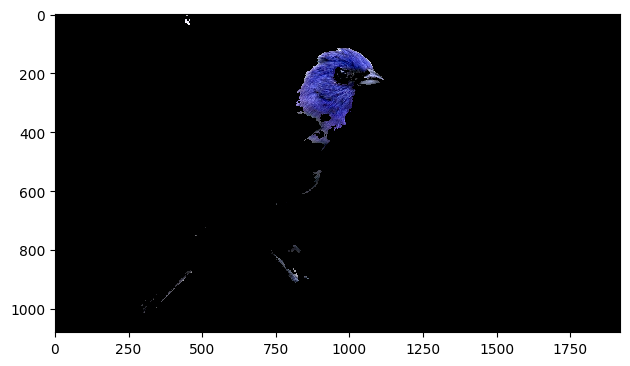

In [ ]:
# creating a mask to detect blue hues
lower_mask = im_hsv[:, :, 0] > 0.58  # lower hue threshold for blue
upper_mask = im_hsv[:, :, 0] < 0.7   # upper hue threshold for blue
mask = upper_mask * lower_mask  # combining both masks

# displaying the mask
plt.imshow(mask, cmap='gray')
plt.show()

# extracting RGB channels based on the mask
red = im[:, :, 0] * mask
green = im[:, :, 1] * mask
blue = im[:, :, 2] * mask

# reconstructing the image with only blue-highlighted regions
im_masked = np.dstack((red, green, blue))

# displaying the masked image
imshow(im_masked)
plt.show()


### **HSV Image Segmentation - Steps**  

1. Start  
2. Load the image  
3. Convert the image to HSV color space  
4. Define color ranges for segmentation  
5. For each color:  
   - Create a mask based on hue thresholds  
   - Apply the mask to extract the selected color  
   - Store the segmented image  
6. Display the original and segmented images  
7. End

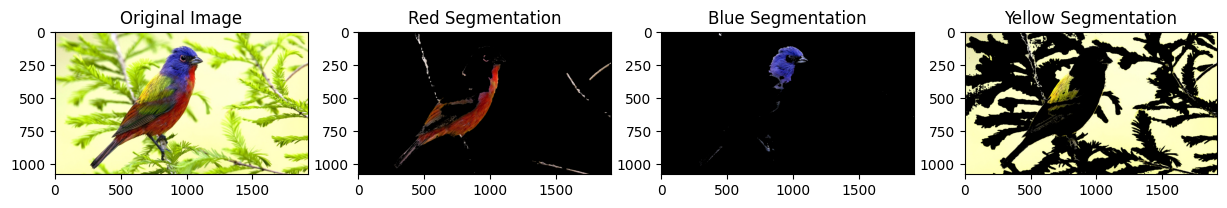

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.io import imread, imshow
from skimage.color import rgb2hsv

# Step 1: Load the image
image = imread("bird_sit.jpg")

# Step 2: Convert the image to HSV color space
image_hsv = rgb2hsv(image)

# Step 3: Define color thresholds (Example: Yellow Color)
color_ranges = {
    "Red": [(0.90, 1.0), (0.0, 0.10)],  # Two ranges for red (since hue wraps around)
    "Blue": [(0.58, 0.7)],
    "Yellow": [(0.12, 0.18)]
}

# Step 4: Initialize an empty segmented image
segmented_images = {}

for color, ranges in color_ranges.items():
    mask = np.zeros_like(image_hsv[:, :, 0], dtype=bool)
    for lower, upper in ranges:
        mask |= (image_hsv[:, :, 0] >= lower) & (image_hsv[:, :, 0] <= upper)

    # Apply the mask to extract color
    red = image[:, :, 0] * mask
    green = image[:, :, 1] * mask
    blue = image[:, :, 2] * mask
    segmented_images[color] = np.dstack((red, green, blue))

# Step 5: Display all segmented images
fig, axes = plt.subplots(1, len(segmented_images) + 1, figsize=(15, 5))

axes[0].imshow(image)
axes[0].set_title("Original Image")

for idx, (color, seg_img) in enumerate(segmented_images.items(), start=1):
    axes[idx].imshow(seg_img)
    axes[idx].set_title(f"{color} Segmentation")

plt.show()

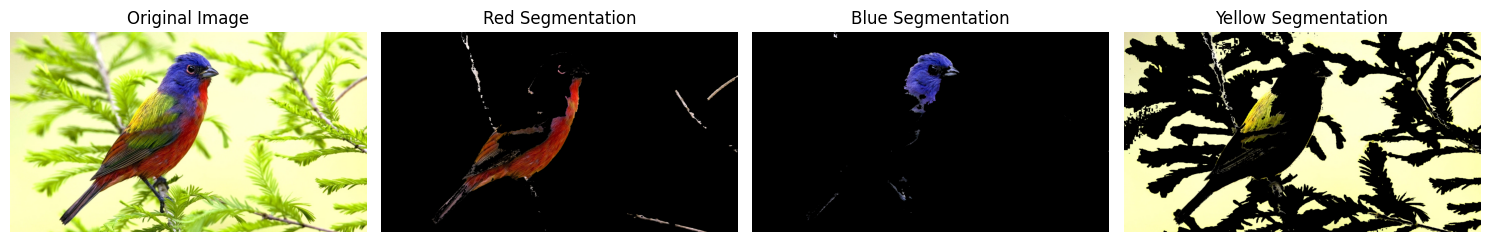

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.io import imread
from skimage.color import rgb2hsv

class HSVSegmenter:
    """
    A class to perform color segmentation on an image using HSV color space.

    Attributes:
        image (np.ndarray): The original input image.
        hsv_image (np.ndarray): The HSV representation of the input image.
    """

    def __init__(self, image_path: str):
        """
        Initializes the HSVSegmenter with the given image path.

        Parameters:
            image_path (str): The path to the input image file.
        """
        self.image = self._load_image(image_path)
        self.hsv_image = rgb2hsv(self.image)

    def _load_image(self, image_path: str) -> np.ndarray:
        """
        Loads an image from the given path.

        Parameters:
            image_path (str): Path to the image file.

        Returns:
            np.ndarray: The loaded image as a NumPy array.
        """
        try:
            image = imread(image_path)
            if image is None:
                raise ValueError("Failed to load image. Ensure the file path is correct.")
            return image
        except Exception as e:
            raise RuntimeError(f"Error loading image: {e}")

    def segment_colors(self, color_ranges: dict) -> dict:
        """
        Segments the image based on the provided HSV hue thresholds.

        Parameters:
            color_ranges (dict): Dictionary mapping color names to hue threshold ranges.

        Returns:
            dict: Dictionary containing segmented images for each color.
        """
        segmented_images = {}

        for color, ranges in color_ranges.items():
            mask = np.zeros_like(self.hsv_image[:, :, 0], dtype=bool)

            # Apply thresholding for each defined hue range
            for lower, upper in ranges:
                mask |= (self.hsv_image[:, :, 0] >= lower) & (self.hsv_image[:, :, 0] <= upper)

            # Extract and stack color channels
            segmented_images[color] = self._apply_mask(mask)

        return segmented_images

    def _apply_mask(self, mask: np.ndarray) -> np.ndarray:
        """
        Applies a binary mask to extract the corresponding color region.

        Parameters:
            mask (np.ndarray): Boolean mask representing the selected color.

        Returns:
            np.ndarray: The segmented image with only the masked color visible.
        """
        segmented = np.zeros_like(self.image)
        segmented[mask] = self.image[mask]
        return segmented

    def display_results(self, segmented_images: dict):
        """
        Displays the original image and segmented images.

        Parameters:
            segmented_images (dict): Dictionary containing segmented images for each color.
        """
        num_colors = len(segmented_images)
        fig, axes = plt.subplots(1, num_colors + 1, figsize=(15, 5))

        # Display original image
        axes[0].imshow(self.image)
        axes[0].set_title("Original Image")
        axes[0].axis("off")

        # Display each segmented image
        for idx, (color, seg_img) in enumerate(segmented_images.items(), start=1):
            axes[idx].imshow(seg_img)
            axes[idx].set_title(f"{color} Segmentation")
            axes[idx].axis("off")

        plt.tight_layout()
        plt.show()

# Main execution block
if __name__ == "__main__":
    # Define the color ranges for segmentation
    color_thresholds = {
        "Red": [(0.90, 1.0), (0.0, 0.10)],  # Red spans two hue ranges
        "Blue": [(0.58, 0.7)],
        "Yellow": [(0.12, 0.18)]
    }

    # Provide image path
    image_path = "bird_sit.jpg"

    # Initialize the segmenter and segment colors
    segmenter = HSVSegmenter(image_path)
    segmented_results = segmenter.segment_colors(color_thresholds)

    # Display results
    segmenter.display_results(segmented_results)
